# Start

In [39]:
from __future__ import print_function
import time
import cfbd
from cfbd.rest import ApiException
from pprint import pprint

# Configure API key authorization: ApiKeyAuth
configuration = cfbd.Configuration()
configuration.api_key['Authorization'] = 'aiS0bBk23RvX4eOWirh4JQgCK+UIO0k1AF/9A2RDyu2D6D/u1LLVKvdDKdHQokqF'  # Replace YOUR_API_KEY with your actual API key
configuration.api_key_prefix['Authorization'] = 'Bearer'

# Create an instance of the API class
api_instance = cfbd.GamesApi(cfbd.ApiClient(configuration))
year = 2023  # int | Year/season filter for games
team = 'Oklahoma'  # str | Team filter (optional)

try:
    # Fetch player game stats
    api_response = api_instance.get_player_game_stats(year=year, team=team)
    # Print the response to understand its structure
    pprint(api_response)
except ApiException as e:
    print("Exception when calling GamesApi->get_player_game_stats: %s\n" % e)



[{'id': 401525900,
 'teams': [{'categories': [{'name': 'punting',
                            'types': [{'athletes': [{'id': 4427146,
                                                     'name': 'Luke Elzinga',
                                                     'stat': '48'}],
                                       'name': 'LONG'},
                                      {'athletes': [{'id': 4427146,
                                                     'name': 'Luke Elzinga',
                                                     'stat': '0'}],
                                       'name': 'In 20'},
                                      {'athletes': [{'id': 4427146,
                                                     'name': 'Luke Elzinga',
                                                     'stat': '0'}],
                                       'name': 'TB'},
                                      {'athletes': [{'id': 4427146,
                                                     'name'

In [4]:
import pandas as pd

try:
    # Fetch player game stats
    api_response = api_instance.get_player_game_stats(year=year, team=team)
    
    # Convert the response to a pandas DataFrame
    # Flatten the nested structure of the response
    data = []
    for game in api_response:
        for team_stats in game.teams:
            for category in team_stats.categories:
                for type_stat in category.types:
                    for athlete in type_stat.athletes:
                        data.append({
                            'game_id': game.id,
                            'team': team_stats.school,
                            'conference': team_stats.conference,
                            'home_away': team_stats.home_away,
                            'points': team_stats.points,
                            'category': category.name,
                            'stat_type': type_stat.name,
                            'player_id': athlete.id,
                            'player_name': athlete.name,
                            'stat': athlete.stat
                        })
    
    df = pd.DataFrame(data)
    #print(df)
except ApiException as e:
    print("Exception when calling GamesApi->get_player_game_stats: %s\n" % e)

        game_id        team conference home_away  points category stat_type  \
0     401525830    Oklahoma     Big 12      home      28  punting      LONG   
1     401525830    Oklahoma     Big 12      home      28  punting      LONG   
2     401525830    Oklahoma     Big 12      home      28  punting     In 20   
3     401525830    Oklahoma     Big 12      home      28  punting     In 20   
4     401525830    Oklahoma     Big 12      home      28  punting        TB   
...         ...         ...        ...       ...     ...      ...       ...   
6714  401525852  Iowa State     Big 12      away      20  passing       AVG   
6715  401525852  Iowa State     Big 12      away      20  passing       YDS   
6716  401525852  Iowa State     Big 12      away      20  passing       YDS   
6717  401525852  Iowa State     Big 12      away      20  passing     C/ATT   
6718  401525852  Iowa State     Big 12      away      20  passing     C/ATT   

      player_id   player_name   stat  
0       4427

In [5]:
df.head(5)

,game_id,team,conference,home_away,points,category,stat_type,player_id,player_name,stat
0,401525830,Oklahoma,Big 12,home,28,punting,LONG,4427146,Luke Elzinga,42
1,401525830,Oklahoma,Big 12,home,28,punting,LONG,4569198,Josh Plaster,46
2,401525830,Oklahoma,Big 12,home,28,punting,In 20,4427146,Luke Elzinga,2
3,401525830,Oklahoma,Big 12,home,28,punting,In 20,4569198,Josh Plaster,2
4,401525830,Oklahoma,Big 12,home,28,punting,TB,4427146,Luke Elzinga,0


   position     height      weight
4        OL  76.600000  307.850000
9        TE  76.428571  243.714286
1        DL  75.047619  277.809524
5         P  75.000000  211.500000
3        LS  74.000000  235.500000
7        QB  74.000000  204.800000
2        LB  73.812500  217.000000
6        PK  72.250000  199.250000
0        DB  71.739130  192.956522
10       WR  71.187500  184.562500
8        RB  70.111111  199.000000
   position     height      weight
4        OL  76.600000  307.850000
1        DL  75.047619  277.809524
9        TE  76.428571  243.714286
3        LS  74.000000  235.500000
2        LB  73.812500  217.000000
5         P  75.000000  211.500000
7        QB  74.000000  204.800000
6        PK  72.250000  199.250000
8        RB  70.111111  199.000000
0        DB  71.739130  192.956522
10       WR  71.187500  184.562500


C:\Users\Ben\AppData\Local\Temp\ipykernel_36724\2355465262.py:43: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




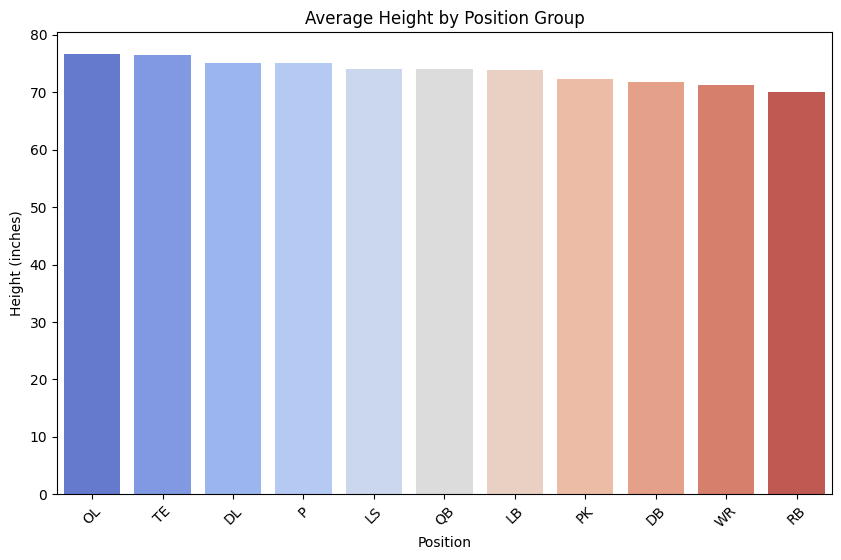

C:\Users\Ben\AppData\Local\Temp\ipykernel_36724\2355465262.py:51: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




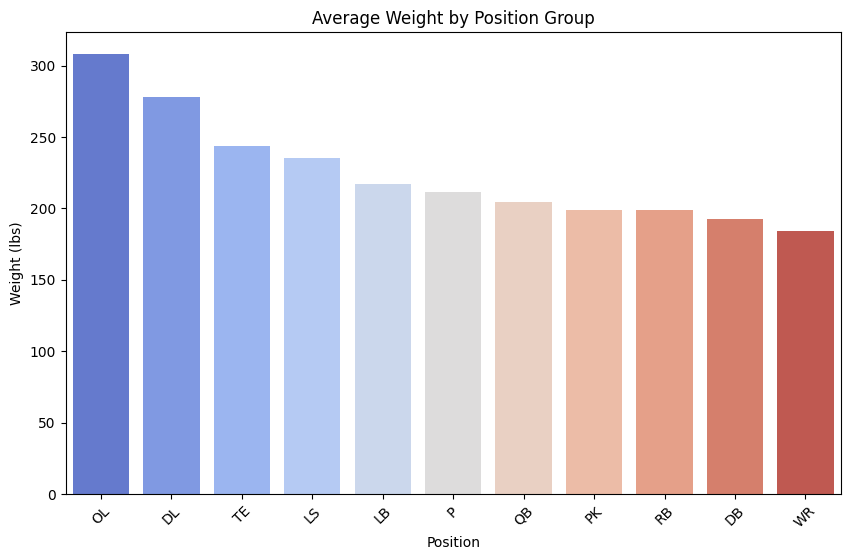

C:\Users\Ben\AppData\Local\Temp\ipykernel_36724\2355465262.py:87: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




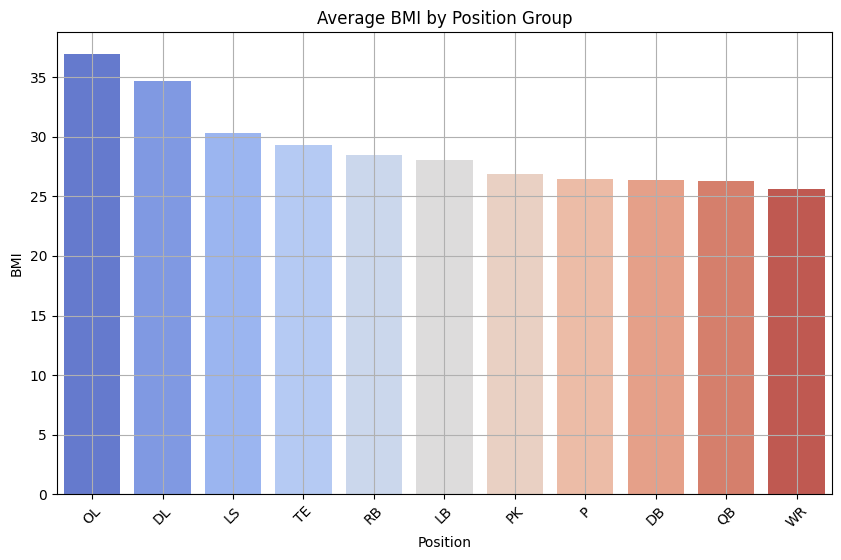

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns


# Create an instance of the API class
api_instance = cfbd.TeamsApi(cfbd.ApiClient(configuration))
team = 'Oklahoma'  # Team filter
year = 2023  # Year filter

try:
    # Fetch team roster
    api_response = api_instance.get_roster(year=year, team=team)
    
    # Convert the response to a pandas DataFrame
    data = []
    for player in api_response:
        data.append({
            'player_id': player.id,
            'first_name': player.first_name,
            'last_name': player.last_name,
            'position': player.position,
            'height': player.height,
            'weight': player.weight
        })

    df = pd.DataFrame(data)
    
    # Group by position and calculate average height and weight
    position_group = df.groupby('position').agg({
        'height': 'mean',
        'weight': 'mean'
    }).reset_index()

    # Sort the DataFrame by height and weight in descending order
    position_group_sorted_by_height = position_group.sort_values(by='height', ascending=False)
    position_group_sorted_by_weight = position_group.sort_values(by='weight', ascending=False)

    print(position_group_sorted_by_height)
    print(position_group_sorted_by_weight)

    # Plotting the data
    plt.figure(figsize=(10, 6))
    sns.barplot(x='position', y='height', data=position_group_sorted_by_height, palette='coolwarm')
    plt.title('Average Height by Position Group')
    plt.xlabel('Position')
    plt.ylabel('Height (inches)')
    plt.xticks(rotation=45)
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.barplot(x='position', y='weight', data=position_group_sorted_by_weight, palette='coolwarm')
    plt.title('Average Weight by Position Group')
    plt.xlabel('Position')
    plt.ylabel('Weight (lbs)')
    plt.xticks(rotation=45)
    plt.show()
except ApiException as e:
    print("Exception when calling TeamsApi->get_roster: %s\n" % e)

    # Scatter plot of height vs weight by position group
    plt.figure(figsize=(10, 6))
    scatter_plot = sns.scatterplot(data=position_group, x='height', y='weight', hue='position', palette='coolwarm', s=100)
    for line in range(0, position_group.shape[0]):
        scatter_plot.text(position_group.height[line], position_group.weight[line], 
                          position_group.position[line], horizontalalignment='left', 
                          size='medium', color='black', weight='semibold')
    plt.title('Average Height vs. Weight by Position Group')
    plt.xlabel('Height (inches)')
    plt.ylabel('Weight (lbs)')
    plt.legend(title='Position', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.show()
except ApiException as e:
    print("Exception when calling TeamsApi->get_roster: %s\n" % e)


# Add BMI calculation
df['BMI'] = df['weight'] / (df['height'] ** 2) * 703

# Group by position and calculate average BMI
position_group_bmi = df.groupby('position').agg({
    'BMI': 'mean'
}).reset_index()

# Plotting the average BMI by position group
plt.figure(figsize=(10, 6))
bmi_plot = sns.barplot(x='position', y='BMI', data=position_group_bmi.sort_values(by='BMI', ascending=False), palette='coolwarm')
plt.title('Average BMI by Position Group')
plt.xlabel('Position')
plt.ylabel('BMI')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


# Plotly PX

In [33]:
# Create an instance of the API class
api_instance = cfbd.TeamsApi(cfbd.ApiClient(configuration))
team = 'Oklahoma'  # Team filter
years = range(2014, 2024)  # Last 10 years

all_data = []

for year in years:
    try:
        # Fetch team roster for the given year
        api_response = api_instance.get_roster(year=year, team=team)
        
        # Process and collect data
        for player in api_response:
            all_data.append({
                'year': year,
                'player_id': player.id,
                'first_name': player.first_name,
                'last_name': player.last_name,
                'position': player.position,
                'height': player.height,
                'weight': player.weight
            })
    except ApiException as e:
        print("Exception when calling TeamsApi->get_roster for year {}: {}\n".format(year, e))

# Convert the collected data to a pandas DataFrame
df = pd.DataFrame(all_data)

# Calculate BMI for each player
df['BMI'] = df['weight'] / (df['height'] ** 2) * 703

# Group by year and position, then calculate average height, weight, and BMI
position_group = df.groupby(['year', 'position']).agg({
    'height': 'mean',
    'weight': 'mean',
    'BMI': 'mean'
}).reset_index()

# Plotting the data using Plotly Express
fig_height = px.line(position_group, x='year', y='height', color='position',
                     title='Average Height by Position Group (2014-2023)',
                     labels={'height': 'Height (inches)', 'year': 'Year'},
                     markers=True, height=600)  # Adjust height here
fig_height.update_traces(mode='lines')
fig_height.show()

fig_weight = px.line(position_group, x='year', y='weight', color='position',
                     title='Average Weight by Position Group (2014-2023)',
                     labels={'weight': 'Weight (lbs)', 'year': 'Year'},
                     markers=True, height=600)  # Adjust height here
fig_weight.update_traces(mode='lines')
fig_weight.show()

fig_bmi = px.line(position_group, x='year', y='BMI', color='position',
                  title='Average BMI by Position Group (2014-2023)',
                  labels={'BMI': 'BMI', 'year': 'Year'},
                  markers=True, height=600)  # Adjust height here
fig_bmi.update_traces(mode='lines')
fig_bmi.show()